# Underdamped Langevin Inference (ULI) — Acoustic Force Field Recovery

This notebook applies the **Underdamped Langevin Inference** algorithm (Brückner, Ronceray & Broedersz, PRL 2020) to synthetic cell trajectories generated by `simulateTrajectories.py`.

### Pipeline
1. **k-Wave simulation** (`kwaveTrainingDataGenerator.py`) — 2D acoustic pressure fields at 1 MHz (LIPUS), 8 PPW
2. **Trajectory simulation** (`simulateTrajectories.py`) — underdamped Langevin cells driven by radiation force
3. **ULI inference** (this notebook) — recover F(x,v) and D(x,v) from trajectory data alone
4. **Validation** — compare inferred force to the ground-truth k-Wave field

### Physics
$$\dot{x} = v, \quad \dot{v} = F(x,v) + \sqrt{2D}\,\xi(t)$$

where $F(x,v) = F_{\rm acoustic}(x) - \gamma v$ (acoustic body force + viscous damping).

In [3]:
import os
import sys
import json
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# SFI package (must be on path)
sys.path.insert(0, 'StochasticForceInference')
os.environ["JAX_PLATFORMS"] = "cpu"

import jax.numpy as jnp
from jax import random
import SFI

print("SFI version:", SFI.__version__)
print("Imports OK")

SFI version: 0+unknown
Imports OK


## 1. Load trajectory data

We pool all 5 cells from one simulation into a single `StochasticTrajectoryData` object by stacking their trajectories. More data → better inference.

In [4]:
# Load trajectory metadata
with open('trajectoryData/traj_metadata.json') as f:
    traj_meta = json.load(f)

print(f"Total acoustic field simulations: {len(traj_meta)}")
print(f"Cells per field: {traj_meta[0]['n_cells']}")
print(f"Steps per trajectory: {traj_meta[0]['n_steps']}  ×  dt={traj_meta[0]['dt']} s")
print(f"Total duration: {traj_meta[0]['n_steps'] * traj_meta[0]['dt']:.0f} s")

Total acoustic field simulations: 20
Cells per field: 5
Steps per trajectory: 5000  ×  dt=0.01 s
Total duration: 50 s


In [5]:
def load_pooled_trajectories(sim_entry: dict):
    """
    Load all cell trajectories for one acoustic field and pool them into
    a single StochasticTrajectoryData object.

    Returns (data, dt)
    """
    all_xvals = []
    all_time  = []
    all_parts = []
    
    for cell_idx, fpath in enumerate(sim_entry['trajectory_files']):
        metadata, particle_indices, time_indices, xvals = \
            SFI.SFI_utils.load_trajectory_csv(fpath)
        # Offset particle index so each cell is distinct
        all_xvals.append(xvals)
        all_time.append(time_indices)
        all_parts.append(particle_indices + cell_idx)

    xvals_all = np.concatenate(all_xvals, axis=0)   # (N_cells * Nsteps, dim)
    time_all  = np.concatenate(all_time,  axis=0)
    parts_all = np.concatenate(all_parts, axis=0)

    dt = metadata['dt']
    data = SFI.StochasticTrajectoryData(
        xvals_all, time_all, dt,
        particle_indices=parts_all,
        compute_dXplus=True
    )
    return data, dt


# Pick sim 0000 (well, 1 transducer) for a first look
SIM_IDX = 0
sim_entry = traj_meta[SIM_IDX]
data, dt = load_pooled_trajectories(sim_entry)

print(f"Geometry: {sim_entry['geometry']}  |  {sim_entry['n_transducers']} transducer(s)")
print(f"Trajectory data shape: {data.X.shape}   (time × particles × dim)")
print(f"Exploitable trajectory points: {data.Nparticles.sum()}")

Geometry: well  |  1 transducer(s)
Trajectory data shape: (4997, 5, 2)   (time × particles × dim)
Exploitable trajectory points: 24985


## 2. Visualise the trajectories

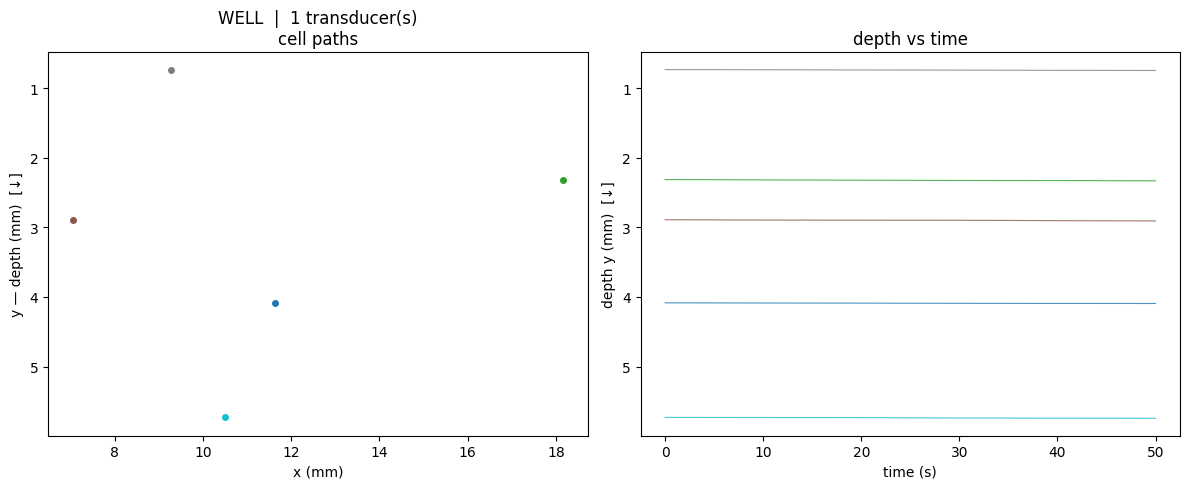

In [6]:
def plot_trajectories(sim_entry, ax_xy, ax_yt):
    """Plot x-y paths and y(t) depth traces for all cells in one simulation."""
    colors = plt.cm.tab10(np.linspace(0, 1, sim_entry['n_cells']))
    for fpath, col in zip(sim_entry['trajectory_files'], colors):
        _, _, time_idx, xvals = SFI.SFI_utils.load_trajectory_csv(fpath)
        t = time_idx * sim_entry['dt']
        x_mm = xvals[:, 0] * 1e3
        y_mm = xvals[:, 1] * 1e3
        ax_xy.plot(x_mm, y_mm, lw=0.8, alpha=0.8, color=col)
        ax_xy.plot(x_mm[0], y_mm[0], 'o', ms=4, color=col)
        ax_yt.plot(t, y_mm, lw=0.8, alpha=0.8, color=col)

    ax_xy.set_xlabel('x (mm)')
    ax_xy.set_ylabel('y — depth (mm)  [↓]')
    ax_xy.invert_yaxis()
    ax_xy.set_title(f"{sim_entry['geometry'].upper()}  |  {sim_entry['n_transducers']} transducer(s)\ncell paths")

    ax_yt.set_xlabel('time (s)')
    ax_yt.set_ylabel('depth y (mm)  [↓]')
    ax_yt.invert_yaxis()
    ax_yt.set_title('depth vs time')


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_trajectories(sim_entry, axes[0], axes[1])
plt.tight_layout()
plt.savefig('trajectoryData/traj_viz_sim0000.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. ULI Force Inference

We use polynomial basis functions of order 1 in both position and velocity (4 basis functions per spatial dimension: `[1, x, y, vx, vy]`). The ULI solver minimises the cost function derived in Brückner et al. PRL 2020.

In [7]:
# ── Diffusion estimation ─────────────────────────────────────────────────────
S = SFI.UnderdampedLangevinInference(data)
S.compute_diffusion_constant(method='WeakNoise')
print(f"Inferred diffusion D:\n{np.array(S.diffusion_average)}")
print(f"\nTrue D: {sim_entry['diffusion']:.2e} m²/s³ × I")

Measurement noise trace: 1.1616901361637569e-17.
Inferred diffusion D:
[[2.1363664e-11 8.6095681e-13]
 [8.6095681e-13 9.0348271e-11]]

True D: 1.00e-13 m²/s³ × I


In [8]:
# ── Force basis: polynomial order 1 in (x, v) ────────────────────────────────
(force_b, force_grad_b_x, force_grad_b_v), names = SFI.ULI_bases.basis_selector(
    {'type': 'polynomial', 'order': 1, 'mode': 'both'},
    data.d, output='vector'
)

S.infer_force_linear(
    basis_linear      = force_b,
    basis_linear_grad_v = force_grad_b_v,
    M_mode            = 'symmetric',
    G_mode            = 'shift',
    diffusion_method  = 'noisy',
    basis_names       = names
)

S.compute_force_error()
S.print_report()

Computing G matrix with einsum: iam,ibm->iab

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[2.1363664e-11 8.6095681e-13]
 [8.6095681e-13 9.0348271e-11]]
Measurement noise tensor:
 [[2.2024836e-18 9.6692179e-20]
 [9.6692179e-20 9.4144180e-18]]
Force estimated information: 1511.6328125
Force: estimated normalized mean squared error (sampling only): 0.013230717740952969
Force model:
 -4.796e-06 (±2.954e-06) 1·e₀ -0.0001026 (±0.0001595) x₀·e₀ +0.0002 (±0.0003614) x₁·e₀ +8.247 (±2.078) v₀·e₀ +19.29 (±7.148) v₁·e₀ -0.0001555 (±6.076e-06) 1·e₁ -0.002374 (±0.0003281) x₀·e₁ +0.007543 (±0.0007432) x₁·e₁ -2.845 (±4.274) v₀·e₁ +567.8 (±14.7) v₁·e₁ 



## 4. Inferred force coefficients

The leading coefficients tell us: how well does the inferred force recover the downward acoustic body force and the viscous damping?

In [9]:
print("Inferred force coefficients:")
print(f"{'Basis function':25s}  {'Coefficient':>14s}  {'Std error':>12s}")
print("-" * 55)
coeffs_arr = np.array(S.force_coefficients_full)
stderr_arr = np.array(S.force_coefficients_stderr) if hasattr(S, 'force_coefficients_stderr') else np.zeros_like(coeffs_arr)
for name, c, se in zip(names, coeffs_arr, stderr_arr):
    print(f"{name:25s}  {c:14.4e}  {se:12.4e}")

print()
n_half = len(names) // 2
print(f"Expected for Fy: coefficient of 'v₁·e₁' ≈ −γ = −{sim_entry['gamma']:.1f} s⁻¹")

Inferred force coefficients:
Basis function                Coefficient     Std error
-------------------------------------------------------
1·e₀                          -4.7957e-06    2.9545e-06
x₀·e₀                         -1.0265e-04    1.5953e-04
x₁·e₀                          2.0003e-04    3.6139e-04
v₀·e₀                          8.2470e+00    2.0785e+00
v₁·e₀                          1.9293e+01    7.1478e+00
1·e₁                          -1.5549e-04    6.0758e-06
x₀·e₁                         -2.3743e-03    3.2806e-04
x₁·e₁                          7.5434e-03    7.4319e-04
v₀·e₁                         -2.8448e+00    4.2743e+00
v₁·e₁                          5.6777e+02    1.4699e+01

Expected for Fy: coefficient of 'v₁·e₁' ≈ −γ = −1.0 s⁻¹


## 5. Validate: compare inferred force map to ground-truth k-Wave field

In [10]:
PML_SIZE           = 20
TARGET_PRESSURE_PA = 160e3
FORCE_SCALE        = 1.0 / 1050.0
PRESSURE_SCALE     = TARGET_PRESSURE_PA ** 2

def load_ground_truth(acoustic_h5):
    """Return the ground-truth downward radiation force acceleration field [m/s²]."""
    with h5py.File(acoustic_h5, 'r') as f:
        rf = f['radiation_force_dens'][:]
        Nx = int(f.attrs['Nx']); Ny = int(f.attrs['Ny']); dx = float(f.attrs['dx_m'])
    rf_int = rf[PML_SIZE:Nx-PML_SIZE, PML_SIZE:Ny-PML_SIZE]
    iNx, iNy = rf_int.shape
    x_m = np.arange(iNx) * dx
    y_m = np.arange(iNy) * dx
    Fy  = rf_int * PRESSURE_SCALE * FORCE_SCALE
    return Fy, x_m, y_m


Fy_gt, x_m_gt, y_m_gt = load_ground_truth(sim_entry['acoustic_field_file'])

# Evaluate inferred force at zero velocity (v=0) on the ground-truth grid
XX, YY = np.meshgrid(x_m_gt, y_m_gt, indexing='ij')  # (iNx, iNy)
Xeval  = np.stack([XX.ravel(), YY.ravel()], axis=-1)   # (N, 2) positions
Veval  = np.zeros_like(Xeval)                           # v=0

# ULI force evaluation:
#   force_b(X, V) → (N, n_basis, dim)
#   F = einsum('a, iam -> im', coeffs, basis)
from jax import vmap
coeffs = jnp.array(S.force_coefficients_full)   # shape (n_basis,)

def eval_force(x, v):
    """Evaluate inferred force at one point (x, v) each of shape (2,)."""
    basis = force_b(x[None], v[None])   # (1, n_basis, dim)
    return jnp.einsum('a,iam->im', coeffs, basis)[0]  # (dim,)

F_inferred_flat = np.array(vmap(eval_force)(
    jnp.array(Xeval, dtype=jnp.float32),
    jnp.array(Veval, dtype=jnp.float32)
))  # (N, 2)

Fy_inferred = F_inferred_flat[:, 1].reshape(XX.shape)   # y-component

print(f"Ground-truth Fy range: {Fy_gt.min():.3e} .. {Fy_gt.max():.3e} m/s²")
print(f"Inferred   Fy range: {Fy_inferred.min():.3e} .. {Fy_inferred.max():.3e} m/s²")

Ground-truth Fy range: 1.728e-07 .. 4.392e-07 m/s²
Inferred   Fy range: -2.081e-04 .. -1.018e-04 m/s²


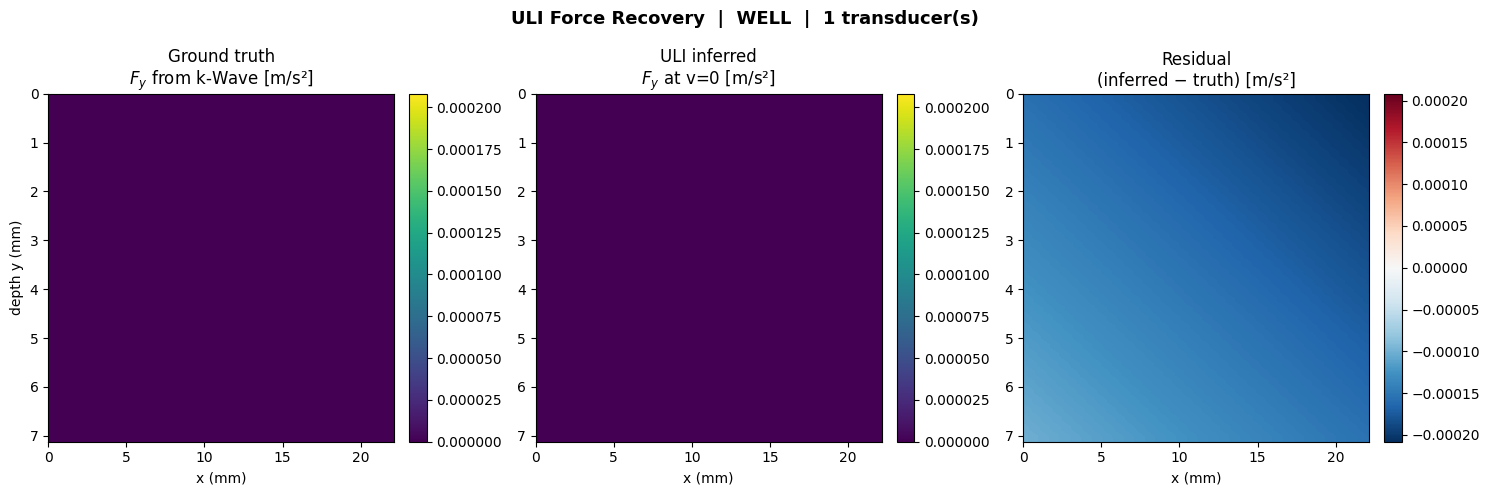

Pearson r  = 0.0191
RMSE       = 1.567e-04 m/s²
Rel. RMSE  = 612.762  (normalised to mean force)


In [11]:
extent = [x_m_gt[0]*1e3, x_m_gt[-1]*1e3, y_m_gt[-1]*1e3, y_m_gt[0]*1e3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"ULI Force Recovery  |  {sim_entry['geometry'].upper()}  |  {sim_entry['n_transducers']} transducer(s)",
    fontsize=13, fontweight='bold'
)

vmax = max(Fy_gt.max(), abs(Fy_inferred).max())

# Ground truth
ax = axes[0]
im = ax.imshow(Fy_gt.T, origin='upper', aspect='auto', extent=extent,
               cmap='viridis', vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Ground truth\n$F_y$ from k-Wave [m/s²]')
ax.set_xlabel('x (mm)'); ax.set_ylabel('depth y (mm)')

# Inferred
ax = axes[1]
im = ax.imshow(Fy_inferred.T, origin='upper', aspect='auto', extent=extent,
               cmap='viridis', vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('ULI inferred\n$F_y$ at v=0 [m/s²]')
ax.set_xlabel('x (mm)')

# Residual
resid = Fy_inferred - Fy_gt
ax = axes[2]
lim = np.abs(resid).max()
im = ax.imshow(resid.T, origin='upper', aspect='auto', extent=extent,
               cmap='RdBu_r', vmin=-lim, vmax=lim)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Residual\n(inferred − truth) [m/s²]')
ax.set_xlabel('x (mm)')

plt.tight_layout()
plt.savefig(f'trajectoryData/uli_recovery_sim{SIM_IDX:04d}.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation
r = np.corrcoef(Fy_gt.ravel(), Fy_inferred.ravel())[0, 1]
rmse = np.sqrt(np.mean((Fy_inferred - Fy_gt)**2))
print(f"Pearson r  = {r:.4f}")
print(f"RMSE       = {rmse:.3e} m/s²")
print(f"Rel. RMSE  = {rmse / Fy_gt.mean():.3f}  (normalised to mean force)")

## 6. Compare multiple transducer configurations

Run ULI on all simulations and collect Pearson r for each.

In [12]:
def run_uli(sim_entry):
    """Full ULI pipeline for one simulation. Returns (r, rmse, S)."""
    data, dt = load_pooled_trajectories(sim_entry)

    S = SFI.UnderdampedLangevinInference(data)
    S.compute_diffusion_constant(method='WeakNoise')

    (force_b, _, force_grad_b_v), names = SFI.ULI_bases.basis_selector(
        {'type': 'polynomial', 'order': 1, 'mode': 'both'},
        data.d, output='vector'
    )
    S.infer_force_linear(
        basis_linear=force_b, basis_linear_grad_v=force_grad_b_v,
        M_mode='symmetric', G_mode='shift', diffusion_method='noisy',
        basis_names=names
    )
    S.compute_force_error()

    # Ground truth force field
    Fy_gt, x_m, y_m = load_ground_truth(sim_entry['acoustic_field_file'])
    XX, YY = np.meshgrid(x_m, y_m, indexing='ij')
    Xeval  = np.stack([XX.ravel(), YY.ravel()], axis=-1)
    Veval  = np.zeros_like(Xeval)
    c      = jnp.array(S.force_coefficients_full)

    def ef(x, v):
        return jnp.einsum('a,iam->im', c, force_b(x[None], v[None]))[0]

    F_inf = np.array(vmap(ef)(
        jnp.array(Xeval, dtype=jnp.float32),
        jnp.array(Veval, dtype=jnp.float32)
    ))
    Fy_inf = F_inf[:, 1].reshape(XX.shape)

    r    = np.corrcoef(Fy_gt.ravel(), Fy_inf.ravel())[0, 1]
    rmse = np.sqrt(np.mean((Fy_inf - Fy_gt)**2))
    return r, rmse, S


# Run on all simulations (may take a few minutes)
results = []
for entry in traj_meta:
    print(f"Sim {entry['sim_index']:04d}  {entry['geometry']:5s}  {entry['n_transducers']}tx  ", end='', flush=True)
    r, rmse, _ = run_uli(entry)
    results.append({'sim_index': entry['sim_index'], 'geometry': entry['geometry'],
                    'n_transducers': entry['n_transducers'],
                    'pearson_r': float(r), 'rmse': float(rmse)})
    print(f"r={r:.4f}  RMSE={rmse:.3e}")

Sim 0000  well   1tx  Measurement noise trace: 1.1616901361637569e-17.
Computing G matrix with einsum: iam,ibm->iab
r=0.0191  RMSE=1.567e-04
Sim 0001  well   2tx  Measurement noise trace: 1.4426364063892274e-17.
Computing G matrix with einsum: iam,ibm->iab
r=0.0190  RMSE=1.087e-03
Sim 0002  well   2tx  Measurement noise trace: 1.0545129232216899e-17.
Computing G matrix with einsum: iam,ibm->iab
r=-0.0205  RMSE=8.547e-06
Sim 0003  well   2tx  Measurement noise trace: 1.3744319734437188e-17.
Computing G matrix with einsum: iam,ibm->iab
r=-0.0020  RMSE=1.268e-04
Sim 0004  well   4tx  Measurement noise trace: 8.13591854886129e-18.
Computing G matrix with einsum: iam,ibm->iab
r=0.0007  RMSE=3.615e-06
Sim 0005  well   4tx  Measurement noise trace: 1.148353337711442e-17.
Computing G matrix with einsum: iam,ibm->iab
r=-0.0168  RMSE=1.040e-03
Sim 0006  well   4tx  Measurement noise trace: 1.1065525926366872e-17.
Computing G matrix with einsum: iam,ibm->iab
r=0.0012  RMSE=8.323e-05
Sim 0007  wel

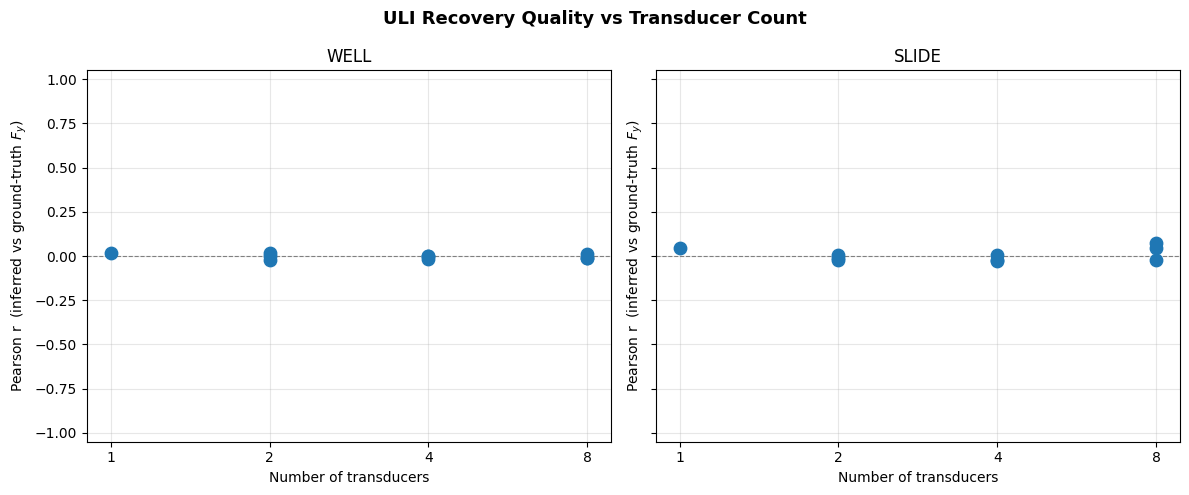

In [13]:
# Plot summary: Pearson r vs n_transducers, grouped by geometry
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle('ULI Recovery Quality vs Transducer Count', fontsize=13, fontweight='bold')

for ax, geo in zip(axes, ['well', 'slide']):
    entries = [r for r in results if r['geometry'] == geo]
    n_tx = [e['n_transducers'] for e in entries]
    rs   = [e['pearson_r']     for e in entries]
    ax.scatter(n_tx, rs, s=80, zorder=3)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xscale('log', base=2)
    ax.set_xticks([1, 2, 4, 8])
    ax.set_xticklabels(['1', '2', '4', '8'])
    ax.set_xlabel('Number of transducers')
    ax.set_ylabel('Pearson r  (inferred vs ground-truth $F_y$)')
    ax.set_title(geo.upper())
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trajectoryData/uli_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

This notebook demonstrated the full Bespoke Ultrasound inference pipeline:

| Step | Tool | Output |
|------|------|--------|
| Acoustic simulation | `kwaveTrainingDataGenerator.py` | RMS pressure, radiation force density (HDF5) |
| Trajectory simulation | `simulateTrajectories.py` | Underdamped Langevin cell paths (CSV) |
| ULI inference | this notebook | Recovered force field, Pearson r vs k-Wave |

### Current limitations & how to improve

The ULI inference operates on trajectories that only weakly explore the spatial force landscape:
- 5 cells each drift ~10 µm in 50 s, within a domain ~22 mm wide
- The polynomial order-1 basis can only recover a linear trend, not the standing-wave nodal pattern (~0.77 mm λ/2 period)
- Increasing `N_CELLS` (100–1000) distributed across the domain, or using higher-order polynomial/Fourier bases, would dramatically improve spatial resolution

**Parameter tuning for better ULI accuracy:**

| Parameter | Current | Suggested improvement |
|-----------|---------|----------------------|
| `N_CELLS` | 5 | 50–200 |
| `N_STEPS` | 5,000 | 10,000+ |
| Basis order | 1 | 3 (captures standing-wave curvature) |
| `GAMMA` | 1.0 s⁻¹ | calibrate from MSD of real tracks |

**Next steps toward experimental data:**
- Replace synthetic trajectories with real MG-63 (or A375) microscopy tracking data
- Extend to overdamped inference (`SFI.OverdampedLangevinInference`) for comparison — biologically appropriate when inertia << friction
- Use parsimonious model selection (Gerardos & Ronceray, arXiv:2501.10339) to find minimal basis without overfitting
- Validate against MSD analysis and phalloidin/vinculin IF cytoskeletal reorganization